<a href="https://colab.research.google.com/github/Abhi-pacific/heart-disease-prediction-project/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [27]:
attribute_info = """
Complete Attribute Documentation — UCI Heart Disease Dataset
=============================================================

 1  id         : patient identification number
 2  ccf        : social security number (replaced with dummy value 0)
 3  age        : age in years
 4  sex        : sex (1 = male; 0 = female)
 5  painloc    : chest pain location (1 = substernal; 0 = otherwise)
 6  painexer   : provoked by exertion (1 = yes; 0 = no)
 7  relrest    : relieved after rest (1 = yes; 0 = no)
 8  pncaden    : sum of painloc, painexer, and relrest
 9  cp         : chest pain type
                   1 = typical angina
                   2 = atypical angina
                   3 = non-anginal pain
                   4 = asymptomatic
10  trestbps   : resting blood pressure (mm Hg on admission)
11  htn        : hypertension
12  chol       : serum cholesterol (mg/dl)
13  smoke      : smoker (1 = yes; 0 = no)
14  cigs       : cigarettes per day
15  years      : number of years as a smoker
16  fbs        : fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
17  dm         : history of diabetes (1 = yes; 0 = no)
18  famhist    : family history of coronary artery disease (1 = yes; 0 = no)
19  restecg    : resting electrocardiographic results
                   0 = normal
                   1 = ST-T wave abnormality
                   2 = left ventricular hypertrophy (Estes criteria)
20  ekgmo      : month of exercise ECG reading
21  ekgday     : day of exercise ECG reading
22  ekgyr      : year of exercise ECG reading
23  dig        : digitalis used during exercise ECG (1 = yes; 0 = no)
24  prop       : beta blocker used during exercise ECG (1 = yes; 0 = no)
25  nitr       : nitrates used during exercise ECG (1 = yes; 0 = no)
26  pro        : calcium channel blocker used during exercise ECG (1 = yes; 0 = no)
27  diuretic   : diuretic used during exercise ECG (1 = yes; 0 = no)
28  proto      : exercise protocol
                   1 = Bruce
                   2 = Kottus
                   3 = McHenry
                   4 = fast Balke
                   5 = Balke
                   6 = Noughton
                   7 = bike 150 kpa min/min
                   8 = bike 125 kpa min/min
                   9 = bike 100 kpa min/min
                  10 = bike 75 kpa min/min
                  11 = bike 50 kpa min/min
                  12 = arm ergometer
29  thaldur    : duration of exercise test in minutes
30  thaltime   : time when ST depression was noted
31  met        : mets achieved
32  thalach    : maximum heart rate achieved
33  thalrest   : resting heart rate
34  tpeakbps   : peak exercise blood pressure (part 1)
35  tpeakbpd   : peak exercise blood pressure (part 2)
36  dummy      : dummy variable
37  trestbpd   : resting diastolic blood pressure
38  exang      : exercise induced angina (1 = yes; 0 = no)
39  xhypo      : exercise hypotension (1 = yes; 0 = no)
40  oldpeak    : ST depression induced by exercise relative to rest
41  slope      : slope of the peak exercise ST segment
                   1 = upsloping
                   2 = flat
                   3 = downsloping
42  rldv5      : height at rest
43  rldv5e     : height at peak exercise
44  ca         : number of major vessels (0-3) colored by fluoroscopy
45  restckm    : irrelevant
46  exerckm    : irrelevant
47  restef     : rest radionuclide ejection fraction
48  restwm     : rest wall motion abnormality
                   0 = none
                   1 = mild or moderate
                   2 = moderate or severe
                   3 = akinesis or dyskinemia
49  exeref     : exercise radionuclide ejection fraction
50  exerwm     : exercise wall motion
51  thal       : thalassemia (3 = normal; 6 = fixed defect; 7 = reversible defect)
52  thalsev    : not used
53  thalpul    : not used
54  earlobe    : not used
55  cmo        : month of cardiac catheterization
56  cday       : day of cardiac catheterization
57  cyr        : year of cardiac catheterization
58  num        : diagnosis of heart disease — TARGET VARIABLE
                   0 = < 50% diameter narrowing (no disease)
                   1 = > 50% diameter narrowing (disease present)
                   (applies to any major vessel; attributes 59-68 are vessels)
59  lmt        : left main trunk
60  ladprox    : proximal left anterior descending
61  laddist    : distal left anterior descending
62  diag       : diagonal branch
63  cxmain     : main circumflex
64  ramus      : ramus
65  om1        : obtuse marginal 1
66  om2        : obtuse marginal 2
67  rcaprox    : proximal right coronary artery
68  rcadist    : distal right coronary artery
69  lvx1       : not used
70  lvx2       : not used
71  lvx3       : not used
72  lvx4       : not used
73  lvf        : not used
74  cathef     : not used
75  junk       : not used
76  name       : last name of patient (replaced with dummy string "name" for Cleveland)

=============================================================
NOTE: Missing values are marked as -9 or -9.0 in the raw file.
      These must be replaced with NaN before any ML processing.

ML COLUMNS USED (14 of 76):
  age, sex, cp, trestbps, chol, fbs, restecg,
  thalach, exang, oldpeak, slope, ca, thal, num (target)
=============================================================
"""

print(attribute_info)


Complete Attribute Documentation — UCI Heart Disease Dataset

 1  id         : patient identification number
 2  ccf        : social security number (replaced with dummy value 0)
 3  age        : age in years
 4  sex        : sex (1 = male; 0 = female)
 5  painloc    : chest pain location (1 = substernal; 0 = otherwise)
 6  painexer   : provoked by exertion (1 = yes; 0 = no)
 7  relrest    : relieved after rest (1 = yes; 0 = no)
 8  pncaden    : sum of painloc, painexer, and relrest
 9  cp         : chest pain type
                   1 = typical angina
                   2 = atypical angina
                   3 = non-anginal pain
                   4 = asymptomatic
10  trestbps   : resting blood pressure (mm Hg on admission)
11  htn        : hypertension
12  chol       : serum cholesterol (mg/dl)
13  smoke      : smoker (1 = yes; 0 = no)
14  cigs       : cigarettes per day
15  years      : number of years as a smoker
16  fbs        : fasting blood sugar > 120 mg/dl (1 = true; 0 = fals

In [7]:
FILE = '/content/drive/MyDrive/ML Projects/Heart disease prediction/heart+disease/new.data'

with open(FILE, 'r') as f:
    content = f.read()

all_cols = [
    'id','ccf','age','sex','painloc','painexer','relrest','pncaden',
    'cp','trestbps','htn','chol','smoke','cigs','years','fbs',
    'dm','famhist','restecg','ekgmo','ekgday','ekgyr','dig','prop',
    'nitr','pro','diuretic','proto','thaldur','thaltime','met',
    'thalach','thalrest','tpeakbps','tpeakbpd','dummy','trestbpd',
    'exang','xhypo','oldpeak','slope','rldv5','rldv5e','ca',
    'restckm','exerckm','restef','restwm','exeref','exerwm',
    'thal','thalsev','thalpul','earlobe','cmo','cday','cyr','num',
    'lmt','ladprox','laddist','diag','cxmain','ramus','om1','om2',
    'rcaprox','rcadist','lvx1','lvx2','lvx3','lvx4','lvf',
    'cathef','junk','v1','v2','v3','v4','v5','v6','v7',
    'v8','v9','v10','v11','v12'
]

records = []
for block in re.split(r'\b[A-Za-z][a-zA-Z]+\b', content):
    vals = block.strip().split()
    if len(vals) < 10:
        continue
    vals = [np.nan if v in ['-9', '-9.0'] else v for v in vals]
    if len(vals) < len(all_cols):
        vals += [np.nan] * (len(all_cols) - len(vals))
    records.append(vals[:len(all_cols)])

df_full = pd.DataFrame(records, columns=all_cols)
df_full = df_full.apply(pd.to_numeric, errors='coerce')

print(f"Patients parsed: {len(records)}")

Patients parsed: 1541


In [8]:
df_full.head()

,id,ccf,age,sex,painloc,painexer,relrest,pncaden,cp,trestbps,...,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12
0,1,15943882.0,63,1,NaN,NaN,NaN,-27.0,1.0,145.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2,15964847.0,67,1,NaN,NaN,NaN,-27.0,4.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,3,15952199.0,67,1,NaN,NaN,NaN,-27.0,4.0,120.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,4,15929464.0,37,1,NaN,NaN,NaN,-27.0,3.0,130.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,6,11961207.0,41,0,NaN,NaN,NaN,-27.0,2.0,130.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [9]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1541 entries, 0 to 1540
Data columns (total 87 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1541 non-null   int64  
 1   ccf       1535 non-null   float64
 2   age       1541 non-null   int64  
 3   sex       1541 non-null   int64  
 4   painloc   1095 non-null   float64
 5   painexer  772 non-null    float64
 6   relrest   762 non-null    float64
 7   pncaden   1193 non-null   float64
 8   cp        1540 non-null   float64
 9   trestbps  1483 non-null   float64
 10  htn       1497 non-null   float64
 11  chol      1341 non-null   float64
 12  smoke     401 non-null    float64
 13  cigs      651 non-null    float64
 14  years     642 non-null    float64
 15  fbs       1449 non-null   float64
 16  dm        1541 non-null   int64  
 17  famhist   670 non-null    float64
 18  restecg   1539 non-null   float64
 19  ekgmo     1393 non-null   float64
 20  ekgday    1388 non-null   floa

In [17]:
# checking for the null values.
pd.set_option('display.max_columns', 100)
print(df_full.isna().sum().to_string())

id             0
ccf            6
age            0
sex            0
painloc      446
painexer     769
relrest      779
pncaden      348
cp             1
trestbps      58
htn           44
chol         200
smoke       1140
cigs         890
years        899
fbs           92
dm             0
famhist      871
restecg        2
ekgmo        148
ekgday       153
ekgyr        148
dig          180
prop         178
nitr         181
pro          177
diuretic     222
proto        208
thaldur       55
thaltime     654
met          150
thalach      151
thalrest     153
tpeakbps     162
tpeakbpd     167
dummy        158
trestbpd     159
exang        157
xhypo        159
oldpeak      158
slope        403
rldv5       1059
rldv5e      1059
ca          1232
restckm     1541
exerckm     1541
restef      1479
restwm      1480
exeref      1537
exerwm      1535
thal        1142
thalsev     1479
thalpul     1523
earlobe     1541
cmo          496
cday         494
cyr          497
num            0
lmt          5

In [22]:
# Lets drop the columns which have more then 600 rows of missing data
df_full.drop(df_full.columns[df_full.isna().sum() > 600], axis=1, inplace=True)


In [23]:
# lets check again
pd.set_option('display.max_columns', 100)
print(df_full.isna().sum().to_string())

id            0
ccf           6
age           0
sex           0
painloc     446
pncaden     348
cp            1
trestbps     58
htn          44
chol        200
fbs          92
dm            0
restecg       2
ekgmo       148
ekgday      153
ekgyr       148
dig         180
prop        178
nitr        181
pro         177
diuretic    222
proto       208
thaldur      55
met         150
thalach     151
thalrest    153
tpeakbps    162
tpeakbpd    167
dummy       158
trestbpd    159
exang       157
xhypo       159
oldpeak     158
slope       403
cmo         496
cday        494
cyr         497
num           0
lmt         515
ladprox     461
laddist     475
cxmain      466
om1         507
rcaprox     481
rcadist     496
lvx1        260
lvx2        261
lvx3        262
lvx4        261
lvf          39
v1           54
v11          51
v12          51


We have removed the columns which have more then 40 percent data missing.

In [24]:
df_full.head()

,id,ccf,age,sex,painloc,pncaden,cp,trestbps,htn,chol,fbs,dm,restecg,ekgmo,ekgday,ekgyr,dig,prop,nitr,pro,diuretic,proto,thaldur,met,thalach,thalrest,tpeakbps,tpeakbpd,dummy,trestbpd,exang,xhypo,oldpeak,slope,cmo,cday,cyr,num,lmt,ladprox,laddist,cxmain,om1,rcaprox,rcadist,lvx1,lvx2,lvx3,lvx4,lvf,v1,v11,v12
0,1,15943882.0,63,1,NaN,-27.0,1.0,145.0,1.0,233.0,1.0,0,2.0,2.0,3.0,1981.0,0.0,0.0,0.0,0.0,0.0,1.0,10.5,13.0,150.0,60.0,190.0,90.0,145.0,85.0,0.0,0.0,2.3,3.0,2.0,16.0,1981.0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,2,15964847.0,67,1,NaN,-27.0,4.0,160.0,1.0,286.0,0.0,0,2.0,3.0,5.0,1981.0,0.0,1.0,0.0,0.0,0.0,1.0,9.5,13.0,108.0,64.0,160.0,90.0,160.0,90.0,1.0,0.0,1.5,2.0,2.0,5.0,1981.0,2,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
2,3,15952199.0,67,1,NaN,-27.0,4.0,120.0,1.0,229.0,0.0,0,2.0,2.0,19.0,1981.0,0.0,1.0,0.0,0.0,0.0,1.0,8.5,10.0,129.0,78.0,140.0,80.0,120.0,80.0,1.0,0.0,2.6,2.0,2.0,20.0,1981.0,1,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,7.0,3.0,0.0,0.0,0.0
3,4,15929464.0,37,1,NaN,-27.0,3.0,130.0,0.0,250.0,0.0,0,0.0,2.0,13.0,1981.0,0.0,1.0,0.0,0.0,0.0,1.0,13.0,17.0,187.0,84.0,195.0,68.0,130.0,78.0,0.0,0.0,3.5,3.0,2.0,4.0,1981.0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4,6,11961207.0,41,0,NaN,-27.0,2.0,130.0,1.0,204.0,0.0,0,2.0,2.0,7.0,1981.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,9.0,172.0,71.0,160.0,74.0,130.0,86.0,0.0,0.0,1.4,1.0,2.0,18.0,1981.0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0


In [29]:
df_full.ekgyr.value_counts()

,count
ekgyr,
1988.0,355
1987.0,191
1985.0,164
1984.0,147
1986.0,143
1983.0,140
1982.0,100
1989.0,85
1981.0,68


In [32]:
pd.crosstab(df_full.ekgyr, df_full.ekgmo)

ekgmo,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
ekgyr,,,,,,,,,,,,
1981.0,5,5,2,0,6,9,7,4,3,3,10,14
1982.0,13,13,9,8,3,7,9,12,5,8,7,6
1983.0,12,9,5,11,7,20,6,17,9,12,13,19
1984.0,22,12,8,12,8,14,10,15,18,11,12,5
1985.0,23,23,42,23,12,8,8,4,3,8,9,1
1986.0,4,10,14,15,15,12,24,5,7,13,11,13
1987.0,16,1,21,12,13,10,17,12,22,25,18,24
1988.0,30,38,32,37,30,33,21,26,44,25,29,10
1989.0,21,14,14,15,19,2,0,0,0,0,0,0


Text(0, 0.5, 'Month')

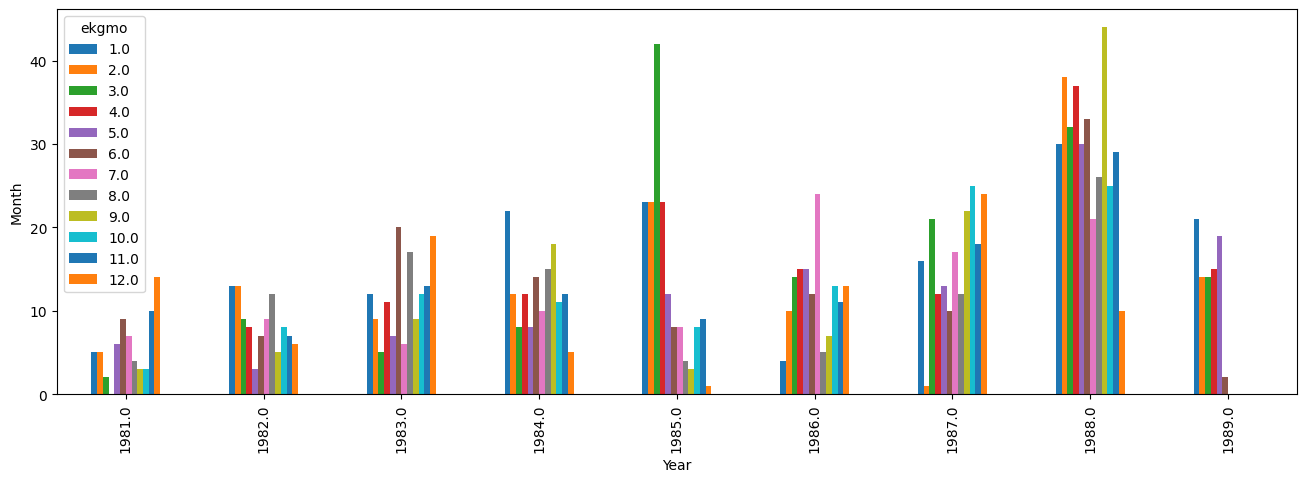

In [40]:
# Lets create visualize this.
pd.crosstab(df_full.ekgyr, df_full.ekgmo).plot(kind='bar',figsize=(16,5))
plt.xlabel('Year')
plt.ylabel('Month')

From this we can see that year 1985 and 1988 has more records